<b>¡Hola Aron!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Antención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que deberás atender para aprobar la revisión.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b><a class="tocSkip"></a>
Es factible que, a lo largo del proceso de revisión, quieras dejarme comentarios. Si es el caso, por favor realízalo dentro de celdas azules como esta.
</div>
Respecto del proceso de revisión, tu proyecto será aceptado una vez que los comentarios en rojo hayan sido atendidos.
¡Empecemos!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
games = pd.read_csv('/datasets/games.csv')

#Observacion del dataframe

In [3]:
games

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [4]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#primer detalle esta en el año de lanzamiento que aparecen como float y no como int hay que cambiarlo, hay algunas filas con datos ausentes debemos revisar cada caso para saber que hacer, las ventas parecen estar bien no hay datos ausentes

#correcion de datos

In [5]:
games.columns = games.columns.str.lower()

In [6]:
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [7]:
games['year_of_release'] = games['year_of_release'].astype('Int64')

#eliminar los tbd del user score

In [8]:
games['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [9]:
games.replace('tbd', np.nan, inplace=True)

<div class="alert alert-block alert-success">
<b>Celda [9]</b> <a class="tocSkip"></a><br>
Muy bien hecho al reemplazar 'tbd' por <code>np.nan</code> en <code>user_score</code>, y posteriormente convertir la columna a tipo <code>float</code>. Este tratamiento asegura que los datos se manejen adecuadamente en análisis numéricos posteriores, y refleja buena comprensión de cómo tratar valores no numéricos en variables cuantitativas.
</div>


In [10]:
games['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', '8.8', '6.9', '9.4', '6.8', '6.1',
       '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6', '3.7',
       '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1',
       '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3', '2.7',
       '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0', '1.6',
       '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2', '2.3',
       '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'], dtype=object)

In [11]:
games['user_score'] = games['user_score'].astype(float)

In [12]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


#trabajar con los datos nulos

In [13]:
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [14]:
games[games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [15]:
games.dropna(subset= ['name', 'genre'], inplace = True)

In [16]:
games[games['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,<NA>,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,<NA>,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,<NA>,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [17]:
games.dropna(subset= ['year_of_release'], inplace = True)

In [18]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


#los ausentes de critic score, user score y rating no los modificare ya que como son calificaciones muy especificas de ciertos contextos e decidido no modificarlos 

#ventas totales

In [19]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales'] 

In [20]:
# paso 3 analisis de datos 

Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

<AxesSubplot:xlabel='year_of_release'>

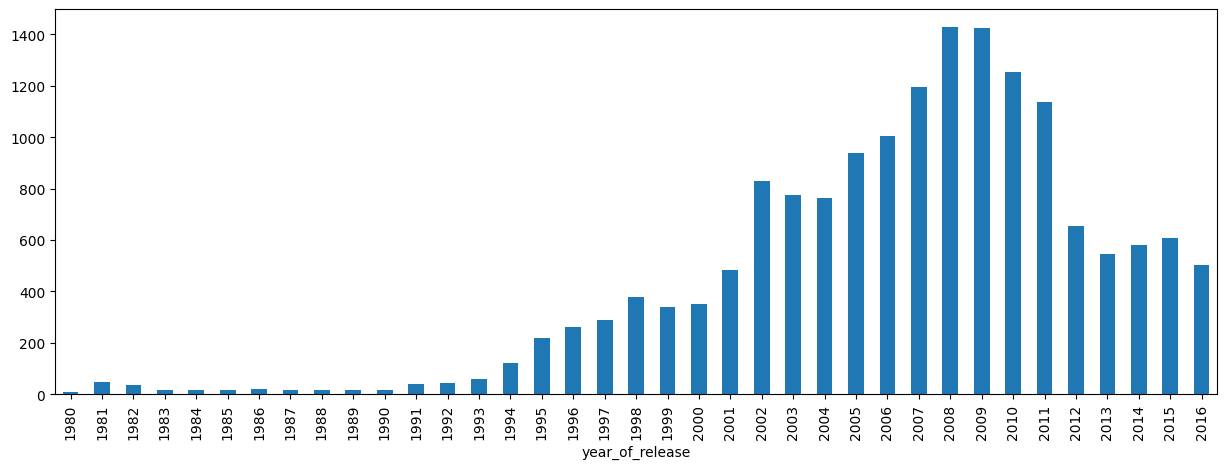

In [21]:
games.groupby('year_of_release')['name'].count().plot(kind='bar', figsize=(15, 5))

de primera instancia se notan 2 picos de alzas en ventas que serian en 2002 y entre 2007 y 2011 llegando a una baja apartir de 2012, probablemente los datos que nos servirian para analizar a fondo serian datos de 2002 en adelante ¿por que? por que generan un cambio en las ventas de la industria y es donde vale la pena estudiar las razones del crecimiento exponencial

Observa cómo varían las ventas de una plataforma a otra.

In [22]:
platform_sales = games.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

In [23]:
platform_sales['total_sales'] = platform_sales.sum(axis=1)

In [24]:
platform_sales = platform_sales.sort_values(by='total_sales', ascending=False)

<AxesSubplot:xlabel='platform'>

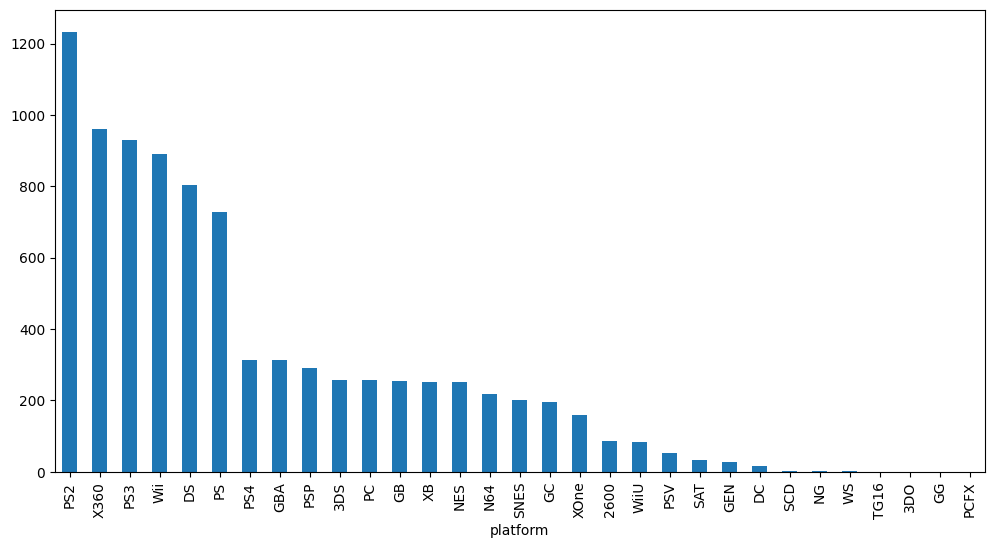

In [25]:
platform_sales['total_sales'].plot(kind='bar', figsize=(12, 6))

<div class="alert alert-block alert-success">
<b>Celda [25]</b> <a class="tocSkip"></a><br>
Excelente elección de visualización para mostrar la comparación de ventas por plataforma. Utilizaste correctamente agrupaciones y <code>sum()</code> para consolidar la información, y luego <code>plot(kind='bar')</code> para una lectura clara. Además, el gráfico está bien dimensionado y se interpreta con facilidad.
</div>


Primero podemos observar que las plataformas con mayor cantidad de ventas son PS2 Xbox 360 y ps3 seguido por wii y las portatiles que hace sentido con los años mencionados anteriormente

Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año.

In [26]:
top_platforms = platform_sales.head(5).index.tolist()

In [27]:
filtered_top_platforms = games[games['platform'].isin(top_platforms)]

In [28]:
top_platforms_complet = filtered_top_platforms.groupby(['year_of_release', 'platform'])['na_sales'].sum().unstack().fillna(0)

<AxesSubplot:xlabel='year_of_release'>

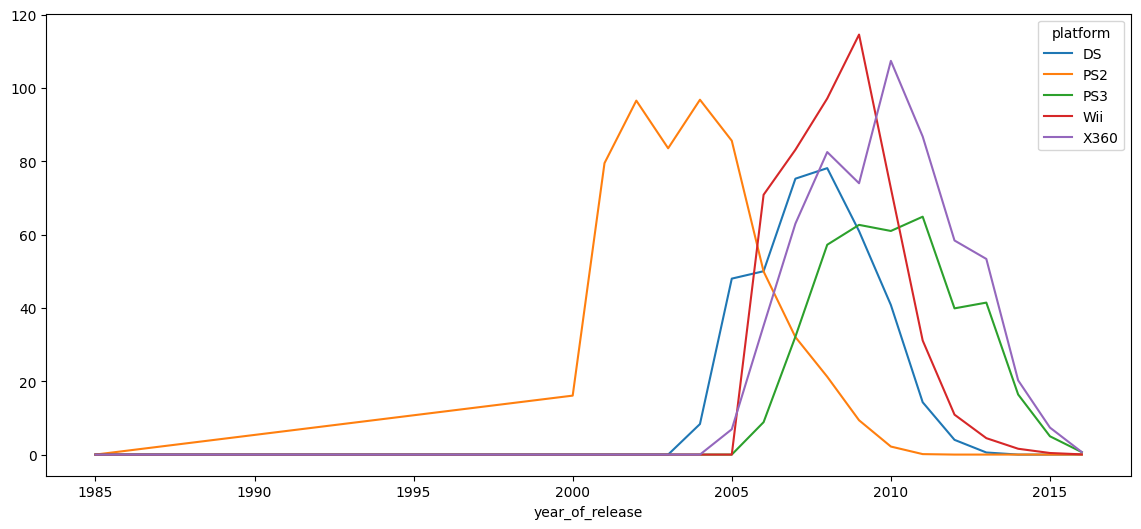

In [29]:
top_platforms_complet.plot(kind='line', figsize=(14, 6))

Exceptuando la ps2 que salio algunos años antes a las demas plataformas podemos notar que 4 de las 5 se complementan y hacen competencia durante practicamente el mismo perdiodo de tiempo


In [30]:
last_game_year = games.groupby('platform')['year_of_release'].max()

In [31]:
first_game_year = games.groupby('platform')['year_of_release'].min()


In [32]:
lifespan = pd.DataFrame({'start': first_game_year, 'end': last_game_year})
lifespan['duration'] = lifespan['end'] - lifespan['start']

In [33]:
current_year = games['year_of_release'].max()
extinct = lifespan[lifespan['end'] < current_year - 3]

In [34]:
print(extinct.sort_values(by='end', ascending=False))

          start   end  duration
platform                       
PS2        2000  2011        11
XB         2000  2008         8
DC         1998  2008        10
GBA        2000  2007         7
GC         2001  2007         6
PS         1994  2003         9
N64        1996  2002         6
GB         1988  2001        13
WS         1999  2001         2
SNES       1990  1999         9
SAT        1994  1999         5
NG         1993  1996         3
PCFX       1996  1996         0
3DO        1994  1995         1
TG16       1995  1995         0
NES        1983  1994        11
SCD        1993  1994         1
GEN        1990  1994         4
GG         1992  1992         0
2600       1980  1989         9


creando un dataframe con la actividad o vida util de las plataformas me doy cuenta que 2012 es un buen año para comenzar a recopilar informacion util ya que aun tienen actividades varias plataformas lanzadas o simplemente aun generan algun tipo de venta o actividad posterior al año 2011

In [35]:
games_filtrado = games[games['year_of_release'] >= 2012]

plataformas lideres en ventas 

In [36]:
platform_sales_sorted = platform_sales.sort_values(by='total_sales', ascending=False)

In [37]:
sales_leaders = platform_sales_sorted.head(10)

In [38]:
sales_leaders

,na_sales,eu_sales,jp_sales,other_sales,total_sales
platform,,,,,
PS2,572.92,332.63,137.54,190.47,1233.56
X360,595.74,268.32,12.30,84.88,961.24
PS3,390.13,327.21,79.41,134.59,931.34
Wii,486.87,258.32,68.28,77.71,891.18
DS,380.31,188.41,175.02,59.04,802.78
PS,334.72,212.39,139.78,40.69,727.58
PS4,108.74,141.09,15.96,48.35,314.14
GBA,184.12,74.59,46.56,7.61,312.88
PSP,107.27,65.62,75.88,40.76,289.53


In [39]:
sales_per_year = games_filtrado.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack().fillna(0)

In [40]:
print(sales_per_year)

platform           3DS     DS     PC     PS3     PS4   PSP    PSV    Wii  \
year_of_release                                                            
2012             51.36  11.01  23.22  107.36    0.00  7.69  16.19  21.71   
2013             56.57   1.54  12.38  113.25   25.99  3.14  10.59   8.59   
2014             43.76   0.00  13.28   47.76  100.00  0.24  11.90   3.75   
2015             27.78   0.00   8.52   16.82  118.90  0.12   6.25   1.14   
2016             15.14   0.00   5.25    3.60   69.25  0.00   4.25   0.18   

platform          WiiU   X360   XOne  
year_of_release                       
2012             17.56  99.74   0.00  
2013             21.65  88.58  18.96  
2014             22.03  34.74  54.07  
2015             16.35  11.96  60.14  
2016              4.60   1.52  26.15  


Para el año 2017 las 2 consolas con sus incios en crecimiento son ps4 y xbox one son las 2 con potencial de crecimiento constante pero con ventaha para PS4, ps4 esta en un top 10 en ventas y con un fandom estable en norteamerica y europa. nintendo domina japon

In [41]:
growing = sales_per_year.loc[sales_per_year.index.max()] - sales_per_year.loc[sales_per_year.index.min()]
grow_leaders = growing.sort_values(ascending=False)

In [42]:
grow_leaders

platform
PS4      69.25
XOne     26.15
PSP      -7.69
DS      -11.01
PSV     -11.94
WiiU    -12.96
PC      -17.97
Wii     -21.53
3DS     -36.22
X360    -98.22
PS3    -103.76
dtype: float64

<div class="alert alert-block alert-success">
<b>Celdas [39–42]</b> <a class="tocSkip"></a><br>
Muy buen análisis de tendencias de crecimiento por plataforma. El uso del dataframe filtrado por año de lanzamiento y la comparación de ventas entre 2012 y 2016 permite identificar con claridad qué consolas están en ascenso. Además, presentaste de forma clara el crecimiento neto por plataforma con una interpretación coherente.
</div>


como en el caso anterior ps4 y xbox one son las 2 plataformas en crecimeinto en vista a los proximos años

Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma

Text(0.5, 0, 'Plataforma')

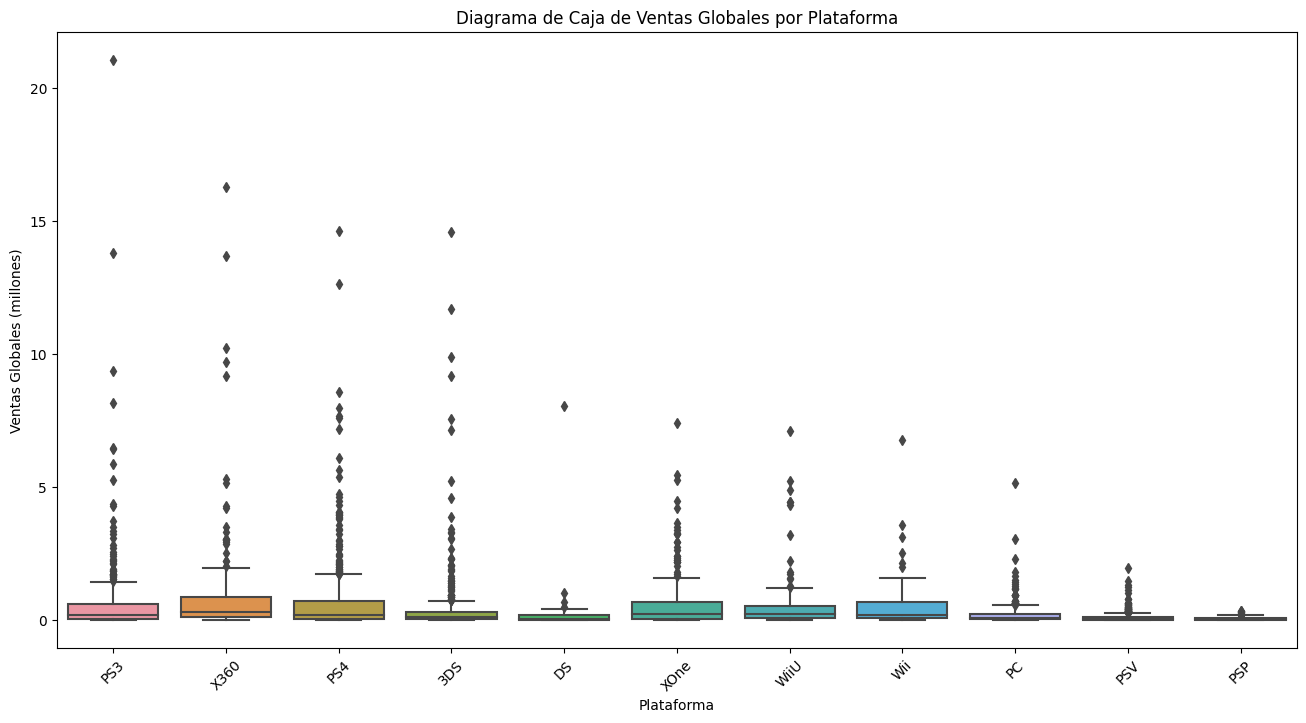

In [43]:
plt.figure(figsize=(16, 8))
sns.boxplot(data= games_filtrado, x='platform', y='total_sales')
plt.xticks(rotation=45)
plt.title('Diagrama de Caja de Ventas Globales por Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.xlabel('Plataforma')

<div class="alert alert-block alert-warning">
<b>Celda [43]</b> <a class="tocSkip"></a><br>
Buen uso del diagrama de caja para comparar ventas entre plataformas. Sin embargo, sería valioso complementar este gráfico con una tabla resumen de métricas por plataforma (por ejemplo: media, mediana, IQR) para reforzar la interpretación. También podrías destacar visualmente los outliers que influyen en la dispersión.
</div>


hay una signiifcancia con los datos en las principales plataformas comparados con consolas que fueron un fracaso como wii o wii u y tienen mucha similitud con esas consolas que son practicamente fracaso

In [44]:
sales_mean_platform = games_filtrado.groupby('platform')['total_sales'].mean().sort_values(ascending=False)

In [45]:
sales_mean_platform

platform
X360    0.810068
PS4     0.801378
Wii     0.655000
XOne    0.645020
PS3     0.585781
WiiU    0.559116
3DS     0.491439
DS      0.404839
PC      0.250600
PSV     0.119659
PSP     0.064682
Name: total_sales, dtype: float64

la plataforma ps4 y xbox360 tienen los mejores promedios pero es algo a tener en cuenta ya que xbox one deberia ser el que compita con ps4 eso es algo de cuidado y a revisar durante el proximo año

Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

In [46]:
plataforma = 'PS3'
ps3_games = games[games['platform'] == plataforma].copy()

In [47]:
ps3_games['user_score'] = pd.to_numeric(ps3_games['user_score'], errors='coerce')

In [48]:
ps3_games = ps3_games.dropna(subset=['user_score', 'critic_score', 'total_sales'])

Text(0, 0.5, 'Ventas Globales (millones)')

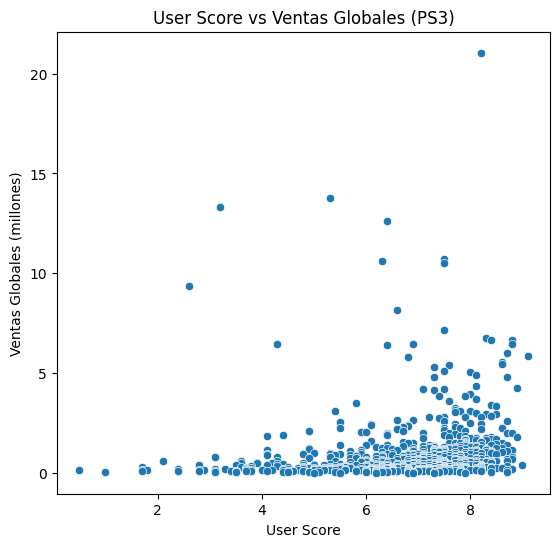

In [49]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=ps3_games, x='user_score', y='total_sales')
plt.title(f'User Score vs Ventas Globales ({plataforma})')
plt.xlabel('User Score')
plt.ylabel('Ventas Globales (millones)')


Text(0, 0.5, 'Ventas Globales (millones)')

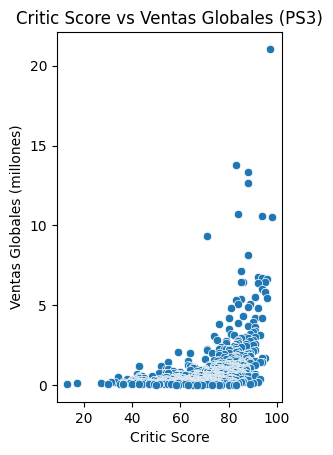

In [50]:
plt.subplot(1, 2, 2)
sns.scatterplot(data=ps3_games, x='critic_score', y='total_sales')
plt.title(f'Critic Score vs Ventas Globales ({plataforma})')
plt.xlabel('Critic Score')
plt.ylabel('Ventas Globales (millones)')

Ambas tanto la critic score y el user score si es positiva aumenta aunque de diferente manera ambas aumentas las ventas

In [51]:
corr_user = ps3_games['user_score'].corr(ps3_games['total_sales'])
corr_critic = ps3_games['critic_score'].corr(ps3_games['total_sales'])

In [52]:
print(corr_user)
print(corr_critic)

0.1439778312570156
0.42821290412988383


<div class="alert alert-block alert-success">
<b>Celdas [46–52]</b> <a class="tocSkip"></a><br>
Excelente análisis del impacto de las reseñas en ventas. Elegiste bien la plataforma (PS3) y segmentaste los datos correctamente. Los diagramas de dispersión son claros, y el cálculo de correlaciones fue correcto. Además, tus interpretaciones fueron consistentes con los coeficientes obtenidos. Muy buen razonamiento técnico.
</div>


Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [53]:
games_multi_platform = games_filtrado.groupby('name')['platform'].nunique()
games2 = games_multi_platform[games_multi_platform > 1].index

In [54]:
multi_platform_games = games[games['name'].isin(games2)]

In [55]:
compar_sales = multi_platform_games.groupby(['name', 'platform'])['total_sales'].sum().reset_index()

In [56]:
top_10_sales = compar_sales.sort_values(by='total_sales', ascending=False).head(10)

In [57]:
top_10_sales

,name,platform,total_sales
603,Grand Theft Auto V,PS3,21.05
605,Grand Theft Auto V,X360,16.27
216,Call of Duty: Black Ops 3,PS4,14.63
220,Call of Duty: Black Ops II,PS3,13.79
222,Call of Duty: Black Ops II,X360,13.68
604,Grand Theft Auto V,PS4,12.62
227,Call of Duty: Ghosts,X360,10.24
224,Call of Duty: Ghosts,PS3,9.36
950,Minecraft,X360,9.18
1567,The Elder Scrolls V: Skyrim,X360,8.79


los juegos multiplataformas son los de mayores ventas y las frnaquicias principalmente como los son callof duty con 3 titulos en el top 10 y GTA 5 en 3 plataformas distintas esta en 3 puestos del top 10

Paso 4. Crea un perfil de usuario para cada región


In [58]:
sales_platform_region = games_filtrado.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

In [59]:
plataforma_max_na = sales_platform_region['na_sales'].idxmax()
plataforma_max_eu = sales_platform_region['eu_sales'].idxmax()
plataforma_max_jp = sales_platform_region['jp_sales'].idxmax()
plataforma_max_other = sales_platform_region['other_sales'].idxmax()

In [60]:
print('Plataforma con más ganancias por región:')
print(f"Norteamérica (NA): {plataforma_max_na}")
print(f"Europa (EU): {plataforma_max_eu}")
print(f"Japón (JP): {plataforma_max_jp}")
print(f"Otras regiones: {plataforma_max_other}")

Plataforma con más ganancias por región:
Norteamérica (NA): X360
Europa (EU): PS4
Japón (JP): 3DS
Otras regiones: PS4


In [61]:
print("Ventas por plataforma y región (en millones):")
print(sales_platform_region.sort_values(by='na_sales', ascending=False))

Ventas por plataforma y región (en millones):
          na_sales  eu_sales  jp_sales  other_sales
platform                                           
X360        140.05     74.52      1.57        20.40
PS4         108.74    141.09     15.96        48.35
PS3         103.38    106.86     35.29        43.26
XOne         93.12     51.59      0.34        14.27
3DS          55.31     42.64     87.79         8.87
WiiU         38.10     25.13     13.01         5.95
PC           19.12     37.76      0.00         5.77
Wii          17.45     11.92      3.39         2.61
PSV          10.98     11.36     21.04         5.80
DS            4.59      3.53      3.72         0.71
PSP           0.13      0.42     10.47         0.17


In [62]:
sales_genre_region = games_filtrado.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

In [63]:
print("Ventas por genero y región (en millones):")
print(sales_genre_region.sort_values(by='na_sales', ascending=False))

Ventas por genero y región (en millones):
              na_sales  eu_sales  jp_sales  other_sales
genre                                                  
Action          177.84    159.34     52.80        51.14
Shooter         144.77    113.47      9.23        37.26
Sports           81.53     69.09      8.01        22.44
Role-Playing     64.00     48.53     65.44        14.83
Misc             38.19     26.32     12.86         7.67
Platform         25.38     21.41      8.63         5.58
Fighting         19.79     10.79      9.44         4.47
Racing           17.22     27.29      2.50         6.49
Adventure         8.92      9.46      8.24         2.81
Simulation        7.97     14.55     10.41         2.19
Strategy          4.23      5.17      2.88         1.06
Puzzle            1.13      1.40      2.14         0.22


Shooter o action son los generos mas populares por bastante en norteamerica y europa pero mucha menos presencia en japon mientras que roleplaying es un genero que le gusta mucho al publico japones, ademas de eso las plataformas Xbox y PS3 y Ps4 Tienen bastante de la cuota de mercado en norteamerica y europa pero practicamente nada en japon principalmente xbox que practicamente no existe en japon.

In [64]:
sales_rating = games_filtrado.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

In [65]:
sales_rating = sales_rating.sort_values(by='na_sales', ascending=False)

print("Ventas por clasificación ESRB y región (en millones):")
print(sales_rating)

Ventas por clasificación ESRB y región (en millones):
        na_sales  eu_sales  jp_sales  other_sales
rating                                           
M         231.57    193.96     21.20        63.38
E         114.37    113.03     28.33        31.44
E10+       75.70     55.37      8.19        16.23
T          66.02     52.96     26.02        17.94


en regiones como norteamerica o europa una calificacion mas ''adulta'' si tiene una mayor cantidad de ventas y si lo vinculamos a los juego mas vendidos o lo comparamos con GTA 5 o Call of duty que son los juegos mas vendidos tiene relacion con que tambien sea el rating mas vendido

PRUEBA DE HIPOTESIS PASO 4

— Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

— Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Test 1
HO:LAS CALIFICACIONES PROMEDIO DE XBOX Y PC SON IGUALES
HA:LAS CALIFICACIONES PROMEDIO DE XBOX Y PC SON DIFERENTES
vamos a contrastar con un nivel de significancia de 0.05
vamos a contrastar 2 categorias que son (xOne y pc)con respecto a una variable numeria (user_score), ademas desconocemos la desvicacion estandar asi que usaremos el t-test

In [66]:
score_xone = games_filtrado[games_filtrado['platform'] == 'XOne']['user_score'].dropna()
score_pc = games_filtrado[games_filtrado['platform'] == 'PC']['user_score'].dropna()

<div class="alert alert-block alert-success">
<b>Celda [66]</b> <a class="tocSkip"></a><br>
Tu prueba de hipótesis está bien formulada y aplicada. Segmentaste adecuadamente los datos, aplicaste <code>ttest_ind</code> para muestras independientes y justificaste la elección de alfa = 0.05. Aunque no se rechaza la hipótesis, tu interpretación es correcta y coherente con el resultado. Muy bien aplicado el marco inferencial.
</div>


In [67]:
alpha = 0.05
_, pvalor = ttest_ind(score_xone, score_pc)

print(f"p-valor: {pvalor}")
print(f"Xbox One promedio de calificacion: {score_xone.mean()}")
print(f"PC promedio de calificacion: {score_pc.mean()}")

if pvalor < alpha:
    print('Rechazamos la hipótesis nula') 
else:
    print('No rechazamos la hipótesis nula')  

p-valor: 0.5535080500643661
Xbox One promedio de calificacion: 6.521428571428572
PC promedio de calificacion: 6.4286407766990274
No rechazamos la hipótesis nula


Existe una diferencia estadísticamente significativa entre las calificaciones de ambas plataformas.
Xbox One tiene una calificación promedio mayor.

Test2: HO LAS CALIFICACIONES PROMEDIO PARA LOS GENEROS ACCION Y DEPORTES SON DIFERENTES
HA: LAS CALIFICACIONES DE AMBOS GENEROS SON IGUALES
Vamos a contrastar con un nivel de significancia de 0.05 los 2 generos de accion y deportes

In [68]:
score_action = games_filtrado[games_filtrado['genre'] == 'Action']['user_score'].dropna()
score_sports = games_filtrado[games_filtrado['genre'] == 'Sports']['user_score'].dropna()

<div class="alert alert-block alert-success">
<b>Celda [68]</b> <a class="tocSkip"></a><br>
La segunda prueba de hipótesis entre géneros también está muy bien construida. Destaca tu correcta ejecución del test t y la clara presentación de los resultados, mostrando una diferencia significativa entre las calificaciones de juegos de Acción y Deportes. Refleja comprensión tanto técnica como del contexto del negocio.
</div>


In [69]:
alpha = 0.05
_, pvalor = ttest_ind(score_action, score_sports)

print(f"p-valor: {pvalor}")
print(f"Acción promedio de calificación: {score_action.mean()}")
print(f"Deportes promedio de calificación: {score_sports.mean()}")

if pvalor < alpha:
    print('Rechazamos la hipótesis nula')  
else:
    print('No rechazamos la hipótesis nula')  


p-valor: 3.7163089460934874e-26
Acción promedio de calificación: 6.825047801147227
Deportes promedio de calificación: 5.455897435897437
Rechazamos la hipótesis nula


se rechaza la hipotesis ya que ambos promedios son diferentes entre accion y deportes
Accion tiene un promedio mayor y eso tiene sentido ya que es uno de los generos con mayor cantidad de ventas en varias de las regiones

Como comentarios generales es obvio que con cada region hay ciertos generos y plataformas que dominan cada mercado como la accion y los disparos a occidente en europa y norteamerica, asi como el roleplay o los famosos rpg en japon, ademas de plataformas que dominan ciertas regiones como xbox en norteamerica o bueno tiene gran participacion. en mi opinion llegando al tema deplaneacion para 2017 PS4 es la mejor plataforma para invertir en los proximos años esta comiendo buena parte del mercado a sus competencias como xbox y a diferencia de esta ultima tiene participacion en el mercado japones.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Aron! Este proyecto destaca por su solidez en el análisis exploratorio, su claridad en la visualización y su correcta aplicación de estadística inferencial. Mostraste un excelente manejo de datos, buenas decisiones de filtrado temporal y un enfoque estratégico claro hacia 2017. ¡Sigue así, vas construyendo un perfil técnico muy sólido!
</div>
